In [1]:
import torch
from transformers import GPT2Model, GPT2Tokenizer
import matplotlib.pyplot as plt
import networkx as nx
from torch.nn.functional import cosine_similarity

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4737.12it/s]

Ready!


In [2]:
text = "The king and queen ruled the kingdom with power and grace"

inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = model(**inputs)

embeddings = outputs.last_hidden_state[0]

# Similarity matrix banao
n = len(tokens)
sim_matrix = torch.zeros(n, n)
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(
            embeddings[i].unsqueeze(0),
            embeddings[j].unsqueeze(0)
        ).item()

print("Tokens:", tokens)
print("Similarity matrix ready!")

Tokens: ['The', 'Ġking', 'Ġand', 'Ġqueen', 'Ġruled', 'Ġthe', 'Ġkingdom', 'Ġwith', 'Ġpower', 'Ġand', 'Ġgrace']
Similarity matrix ready!


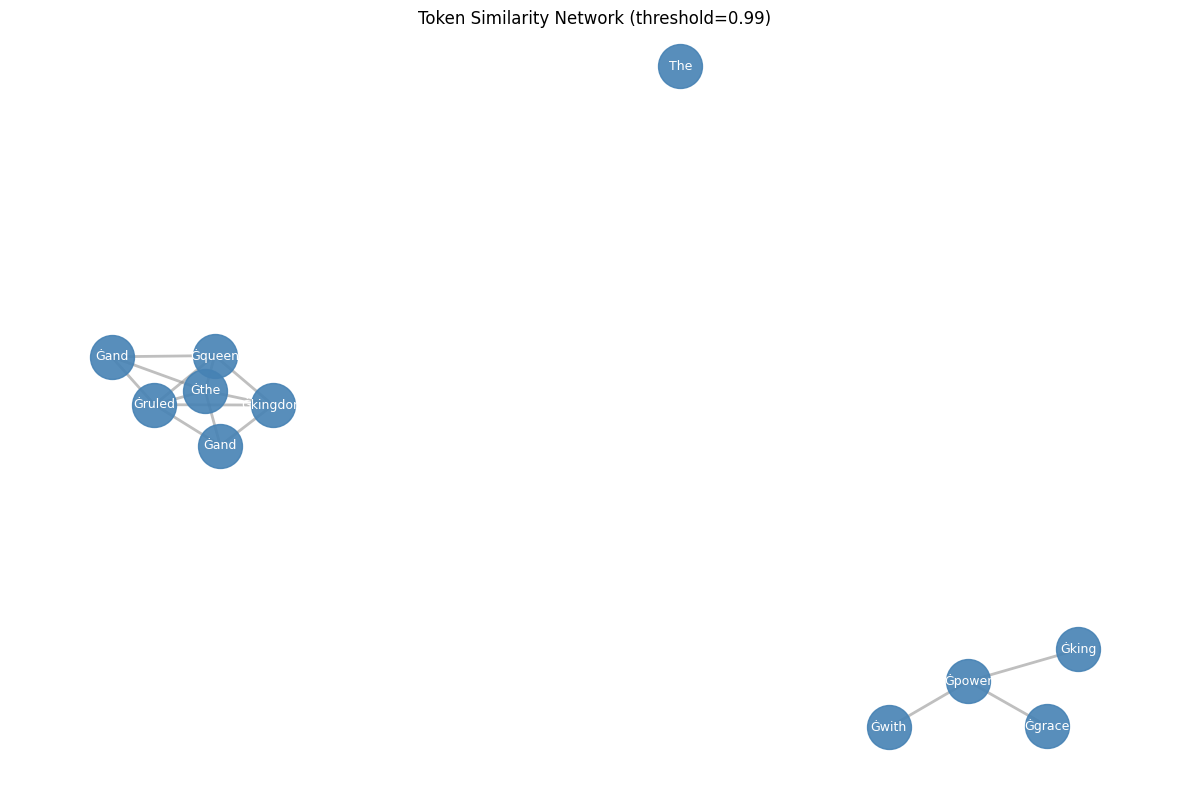

Total nodes: 11
Total edges: 15


In [4]:
# Threshold — sirf high similarity wale edges dikhao
threshold = 0.99

G = nx.Graph()

# Nodes add karo
for i, token in enumerate(tokens):
    G.add_node(i, label=token)

# Edges add karo sirf threshold ke upar
for i in range(n):
    for j in range(i+1, n):
        if sim_matrix[i, j].item() >= threshold:
            G.add_edge(i, j, weight=sim_matrix[i, j].item())

# Draw karo
fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)
labels = {i: tokens[i] for i in range(n)}

nx.draw_networkx_nodes(G, pos, node_size=1000, 
                       node_color="steelblue", alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, labels, 
                        font_color="white", font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.5, 
                       edge_color="gray", width=2, ax=ax)

ax.set_title(f"Token Similarity Network (threshold={threshold})")
ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")

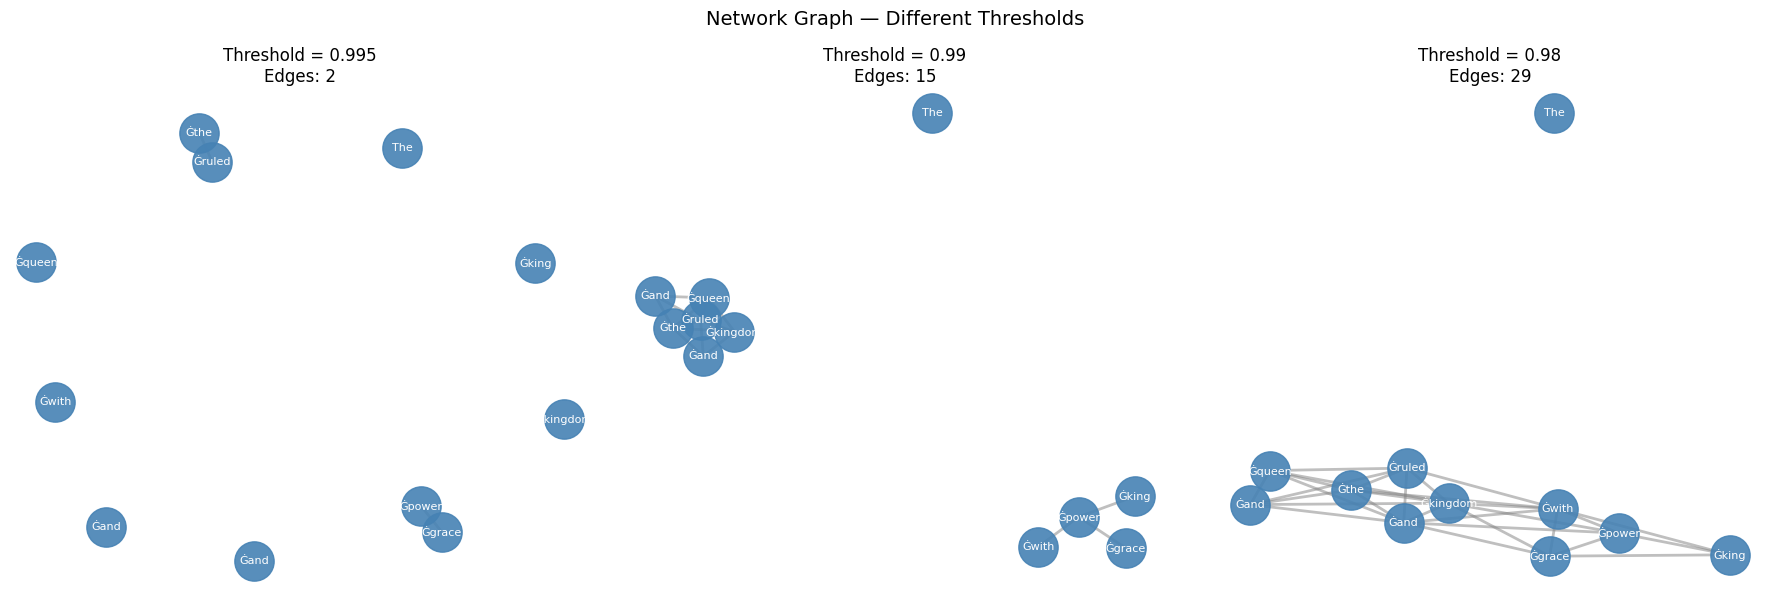

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

thresholds = [0.995, 0.990, 0.980]

for ax, threshold in zip(axes, thresholds):
    G = nx.Graph()
    
    for i in range(n):
        G.add_node(i)
    
    for i in range(n):
        for j in range(i+1, n):
            if sim_matrix[i, j].item() >= threshold:
                G.add_edge(i, j)
    
    pos = nx.spring_layout(G, seed=42)
    labels = {i: tokens[i] for i in range(n)}
    
    nx.draw_networkx_nodes(G, pos, node_size=800,
                           node_color="steelblue", alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, labels,
                            font_color="white", font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.5,
                           edge_color="gray", width=2, ax=ax)
    
    ax.set_title(f"Threshold = {threshold}\nEdges: {G.number_of_edges()}")
    ax.axis("off")

plt.suptitle("Network Graph — Different Thresholds", fontsize=14)
plt.tight_layout()
plt.show()

* **Network graphs** help visualize how tokens form **clusters** based on similarity.

* A **threshold value** controls how many connections (edges) are shown between tokens.

* Tokens with **similar meanings naturally group together** into clusters.

* For example, words like *king*, *queen*, and *kingdom* would appear in the **same cluster** because of their strong semantic relationship.
